<a href="https://colab.research.google.com/github/r-okotie179/projectTantalus/blob/main/synthetic_disease_outbreak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I have a (quite old) interest in epidemiology and I feel that it will be better to use synthetic data to model this relationship between edges: it will cause me to consider how to encode probabilities and equations against nodes.

### Inspiration

I intend to write a piece on either/both Foot and Mouth Disease (FMD) and Mad Cow Disease. The introductory part of this video would explore modelling attempts for a newly emerging disease and the importance of decisions (which then progresses to how these predictions affect policy and the downstream political responses to farmer's responses to mass culling as a preventative measure).

Reading through papers have initially done nothing for me and so constructing a vague approximation for what will happen is a much better approach. This will then be validated by citations from sources.

Then the model can be refined with increasing complexity (and would allow me to reach out to Christl Donnelly or other researchers (like Prof. Neil Ferguson) and their testimonials on both the maths and their downstream effects).

Thus, below is the model.

# Model I
Inspired by the distribution of farmlands and their connection networks. The disease I will work towards is BSE (less variables) and see how the sharing of food-stock (and how the use of animal meal can transfer between farms), as well as the delayed emergence of symptoms and what response would be best suited for this.

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

Used `Claude Sonnet 5 Extra Thinking` to know roughly what the median value of cattle there were in the UK; I assumed it would follow an exponential distribution (where a small amount of farms would have large cattle sizes, but probably less centralised food sources; it would contain very high amounts of shared transportation and shared food sources).

**Improvements**: Distribution with the below equation now presents more apparently the larger, more infrequent farming clusters:

```
f = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)
```

/tmp/ipykernel_484/1902085021.py:7: RuntimeWarning: divide by zero encountered in divide
  f_range = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)


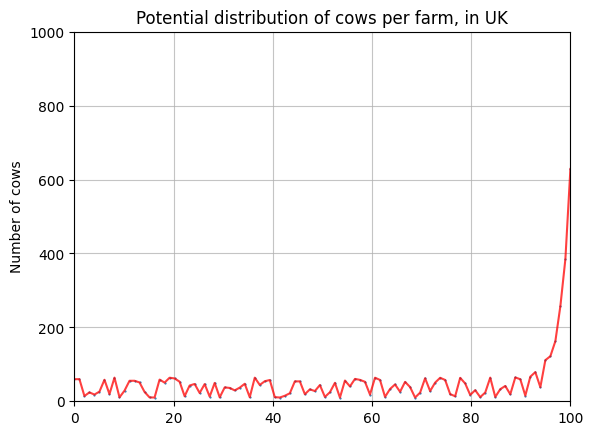

In [ ]:
# distribution of number of cattle
## it can and will be improved with other distributions
## I will sample uniformly from f

x = np.linspace(0, 100, 100)
a = 37 # median
f_range = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)

plt.xlim(0, 100)
plt.ylim(0, 1000)
plt.scatter(x, f_range, s=.3)
plt.plot(x, f_range, color='r', alpha=.75)
plt.title("Potential distribution of cows per farm, in UK")
plt.ylabel("Number of cows")
plt.grid(alpha=0.75)
plt.show()

#print(f_range)

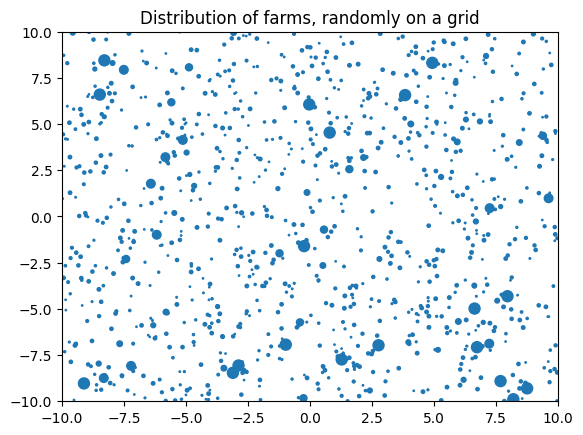

In [ ]:
scale = 10 # size of gridding

def farmland(n): # output n nodes
  farmlands = []
  for each_farm in range(n):
    # num cattle, position, centrality (1 indicates entire food source is shared and eaten from one big piece, 0 implies each individual sheep has its own feeding  )
    nc = np.random.choice(f_range).astype(int)
    position = (np.random.uniform(-scale,scale), np.random.uniform(-scale,scale))
    farmlands.append([nc,position])
  df_farms = pd.DataFrame(farmlands, columns=['Cattle No.', 'Position'])
  return df_farms # as dataframe

test = farmland(1000)
pos = np.array(test['Position'].tolist())

plt.scatter(pos[:,0], pos[:,1], s=np.array(test['Cattle No.'])/scale)
plt.xlim(-scale,scale)
plt.ylim(-scale,scale)
plt.title("Distribution of farms, randomly on a grid")
plt.show()

## Connections of each graph
A directed graph is one in which the magnitude of the edge weight going from nodes A -> B is not necessarily the same as B -> A.

I want to represent the farms like this since large farms would be (**in my head, based off of nothing**) more likely to be the focal point of distribution networks.

I want the connections between farms to be a function of their proximity and size and iterate this over all farms (a wholly inefficient algorithm).

The first step of this is to have a function for the probability of an edge occuring in one direction between two nodes:

$$\text{Let u} =\frac{x_{n} \text{dist}(x_{p}, y_{p})}{y_{n}}$$

Where $x_n$ is the number of cattle on a given farm, $x_p$ is its position and the function $\text{dist}(x,y)$ computes the distance between two coordinate values.

$$P(x_i, x_j) = f(u)$$

The $\frac{x_n}{y_n}$ term encodes that *size matters* and then larger farms would be more likely to send resources to smaller farms (likely in some assimilation attempt to grow). This was inspired by the idea of equilibrium. If $x_n << y_n$ it reduces the overall chance of an edge occuring in that direction.

The distance between the nodes is trivial.

For $f(x)$, I would like a function that can compress positive, real inputs to outputs between 0 and 1.

I will print out some potential functions that has this quality and try to understand why some are used over others.

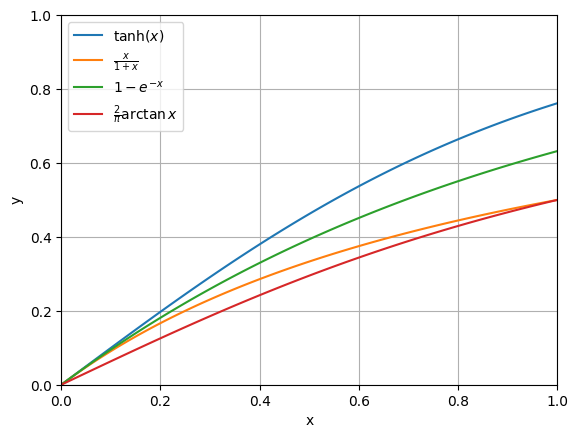

In [ ]:
'''
f(x) contenders:
tanhx, 2(arctanx)/pi, 1-e^-x, x/(1+x)
I used Claude to get this list, although it's quite standard
'''
z = np.linspace(0, 1, 100)
tanh = (np.exp(2 * z) - 1)/(np.exp(2 * z) + 1)
polyn = z/(1+z)
arctan = (2/np.pi) * np.arctan(z)
exp = 1 - np.exp(-z)

plt.plot(z, tanh, label=r'$\tanh(x)$')
plt.plot(z, polyn, label=r'$\frac{x}{1+x}$')
plt.plot(z, exp, label=r'$1-e^{-x}$')
plt.plot(z, arctan, label=r'$\frac{2}{\pi}\arctan{x}$')


plt.ylim(0,1)
plt.xlim(0,1)
#plt.axis('equal')

plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.legend()
plt.show()

Since this range is much smaller than what my input would be (is my assumption, I will do tests before this), I was thinking of taking the natural logarithm of my raw inputs and the seeing what the output would be and calling it a day.

### Creating edges
This section will include many, many tangents all in the name of constructing the edges for this code.

Below is the rough pseudocode that all of this leads towards, where there is a construction of edges each with a randomly derived edge weight.

In [ ]:

'''
for node in df_farms:
  neighbours = get_knn(node, k) # k ~ 10-15
  for idx in range(k):
    comp_node = neighbours[idx]
    p = f(node, comp_node)
    rand = np.random.uniform(0,1)
    if rand <= p:
      edge_update(node, comp_node, rand)
'''

This function very simply computes the u value. It will probably be an internal function within a class (or called within the `p(x,y)` function).

In [ ]:
# calculate u
def u(a,b): # a and b are coordinates
  a_num = a['Cattle No.']
  b_num = b['Cattle No.']
  a_pos = a['Position']
  b_pos = b['Position']

  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  return u.astype('float')

Now the tangent is such that, when I want to find nodes that are in a given range from the point, I would have to search the entire space of nodes and then compute their distances and add to the list those which I think are appropriate.

Which is silly.

So I was thinking of:
- ordering the database in terms of location (how)
- understanding different sorting algorithms, how they work and their optimisation
- getting this finished in the next session where I have connected edges to each point (and maybe an assigning of edges, stored into the node values as a dictionary since its directed).

#### KD-Tree
A k-dimensional tree is a data structure that partitions are list of data into k-dimensions such that it is faster to search through. For my algorithm searching for the *m* nearest node will reduce from $O(n^2)$ to $O(n\log{n})$ and will help me when I grow this.

Also, meant I thought about optimising things.

I will be following the work of @brewingacupofdata

In [ ]:
pip install binarytree

In [ ]:
from binarytree import tree, Node # idk what this does
from math import floor # ik what this does

In [ ]:
'''
@brewingacupofdata might be the goat; I have followed through his tutorial rather than using Claude's
'''

class MyNode(Node):
  def __init__(self, _id, data, axis, idx):
    super().__init__(_id)
    self.data = data
    self.axis = axis
    self.idx = idx

class KD_Tree:
  def __init__(self, data):
    self.data = data
    self.tree = None

  def _build(self, points, depth): # this is an internal function meaning it can only be called in this class
    k = len(points.columns) # assuming data is in pandas.DataFrame
    _axis = depth % k
    _column = points.columns[_axis]


    if len(points) == 0:
      return None
    objects_list = points.sort_values(by=[_column], ascending=True) # sorting data based on pandas notation
    if len(objects_list)%2 == 0:
      median_idx = int(len(objects_list)/2)
    else: # if odd
      median_idx = floor(len(objects_list)/2)

    # numpy stores data like numpy.float64 which isn't unpacked in different libraries
    node = MyNode(_id = round(objects_list.iloc[median_idx][_column].item(), 3),
                  data = objects_list.iloc[median_idx],
                  axis = _column,
                  idx = median_idx)
    node.left = self._build(objects_list.iloc[0:median_idx], depth+1)
    node.right = self._build(objects_list.iloc[median_idx+1:], depth+1)
    return node

  def build(self):
    self.tree = self._build(self.data, depth=0)

  #####

  def _nearest(self, query, node, best_node, best_distance):
    # node = current_node
    if not node:
      return best_node, best_distance

    d = np.linalg.norm(query.values[0] - node.data.values).item() # assuming query is pd.DataFrame row

    if d < best_distance:
      best_node = node
      best_distance = d

    # now deciding which side of tree to progress down

    if query[node.axis].values[0] < node.data[node.axis]:
      good_side = node.left
      bad_side = node.right
    else:
      good_side = node.right
      bad_side = node.left

    best_node, best_distance = self._nearest(query, good_side, best_node, best_distance)

    if abs(node.data[node.axis] - query[node.axis].values[0]) < best_distance:
      best_node, best_distance = self._nearest(query, bad_side, best_node, best_distance)

    return best_node, best_distance # a successful recursive algorithm

  #####

  def _k_nearest(self, query, node, k_list, k):
    if not node:
        return k_list

    d = np.linalg.norm(query.values[0] - node.data.values).item()

    if len(k_list) < k:
        k_list.append([node, d])
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        if d < k_list[worst_idx][1]:
            k_list[worst_idx] = [node, d]

    if query[node.axis].values[0] < node.data[node.axis]:
        good_side, bad_side = node.left, node.right
    else:
        good_side, bad_side = node.right, node.left

    k_list = self._k_nearest(query, good_side, k_list, k)

    # prune condition: only descend bad_side if it could still contain
    # a point closer than your current worst (or you don't have k yet)
    if len(k_list) < k:
        should_check_bad_side = True
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        should_check_bad_side = abs(node.data[node.axis] - query[node.axis].values[0]) < k_list[worst_idx][1]

    if should_check_bad_side:
        k_list = self._k_nearest(query, bad_side, k_list, k)

    return k_list

  ######

  def get_nn(self, query): # actually calling the nearest neighbour
    return self._nearest(query, self.tree, best_node = None, best_distance = np.inf)

  def get_knn(self, query, k):
    return self._k_nearest(query, self.tree, k_list=[], k=k)

The KNN function was mostly written by me, but I gave the polishing it up to `Claude` since I need to focus more on the model, rather than searching for neighbours. This detour took like 2 days because I'm an idiot.

In [ ]:
positions_df = pd.DataFrame(test['Position'].tolist(), columns=['x', 'y'])
kd = KD_Tree(positions_df)
kd.build() # build tree of nodes

In [ ]:
query = pd.DataFrame([test['Position'][9]], columns= positions_df.columns)
res = kd.get_nn(query)
res2 = kd.get_knn(query, 15)
print(res) # result
print(res[0].data.values) # the actual coordinate

data = [[item[0], item[1]] for item in res2]
print(data[4][0]['Cattle No.'])

(Node(-8.333), 0.0)
[-6.63579684 -8.33286958]


NodeIndexError: node index must be a non-negative int

Now this has done, I can return to the creation of edges (now that I know who my neighbours are) and then continue from there.

### Actual implementaton of edges

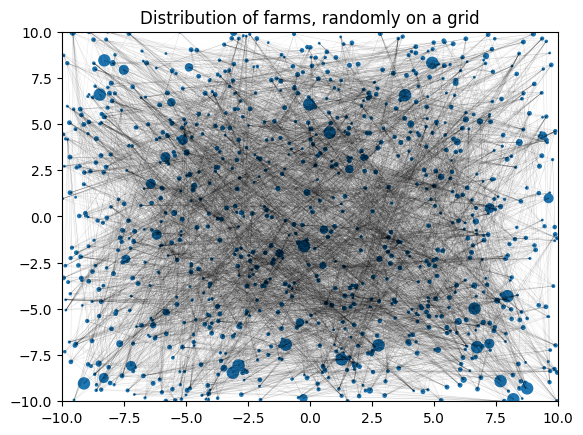

In [ ]:
'''
for node in df_farms:
  neighbours = get_knn(node, k) # k ~ 10-15
  for idx in range(k):
    comp_node = neighbours[idx]
    p = f(node, comp_node)
    rand = np.random.uniform(0,1)
    if rand <= p:
      edge_update(node, comp_node, rand)
'''

# calculate u
def u(a,b): # a and b are coordinates
  a_num = a['Cattle No.']
  b_num = b['Cattle No.']
  a_pos = np.array(a['Position'])
  b_pos = np.array(b['Position'])

  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  return u.astype('float')

def f(a,b):
  # this function just scales the output of u(x,y) so that it is between 0 and 1
  z = u(a,b)
  q = (2/np.pi) * np.arctan(z)
  return q

k=10

for node_idx in range(len(test)):
    node = test.iloc[node_idx]
    query = pd.DataFrame([node['Position']], columns=positions_df.columns)
    neighbours = kd.get_knn(query, k)

    for idx in range(k):
        comp_node_obj, comp_dist = neighbours[idx]
        comp_node = test.loc[comp_node_obj.data.name]

        p = f(node, comp_node)
        rand = np.random.uniform(0, 1)
        if rand <= p:
            x = (node['Position'][0], comp_node['Position'][0])
            y = (node['Position'][1], comp_node['Position'][1])
            plt.plot(x, y, linewidth=.25, c='black', alpha = rand/5)

plt.scatter(pos[:,0], pos[:,1], s=np.array(test['Cattle No.'])/scale, alpha=1)
plt.xlim(-scale,scale)
plt.ylim(-scale,scale)
plt.title("Distribution of farms, randomly on a grid")
plt.show()

https://kingaa.github.io/clim-dis/

This link shows more detail on next steps beyond the FMD model.

### Rejection of BSE Model

It would be a diversion from my construction: since food meal is centralised through a few suppliers that every farm woul likely take from, it would form a bipartite graph. This structure is something I am already exploring in a different project (`charity_idea.ipynb`) and so a more conventional network transmission model would be more interesting to explore.

Thus, I will no longer explore BSE.

### FMD Model
I will model the chance of an infection occuring to be in one of two ways:
- direct contact (e.g. lorry transporting equipment between farms that contains virus on it)
- wind (i.e. virus is spread through air; much lower probability of infection but has a high impact).

For the wind assuming, the probability of infection will follow an inverse square distribution ($\frac{1}{d^2}$) and be scaled by a small factor. Seeing how this factor changes the disease spread will be interesting.

#### Within Farms
Within each farm, the logic be similar to the Eyam model.

The farm size is already defined at $N$.

$$N = S + I + D$$

This model is such that no cattle survives and thus the only states present are susceptible, infected and dead.

----

**Future Model**: I hope to get a model that can include both recovered and culled cattle, so that the response to policy could be quantified.

----

Similar to Andrew French's model, that I explored in more detail in `chapter_2_5.ipynb`, I will state these as the expected change in values of $S, I, \& D$.

$$\Delta S = - \beta S I \Delta t$$
$$\Delta D = \alpha I \Delta t$$
$$\Delta I = (\beta S - \alpha)I\Delta t$$

These will then be sampled with a Poisson distribution across each timestep.

#### Between Farms
The probability of a neighbouring farm being infected is dependent on:

- the ratio of infectives in the farm compared infectives in neighbour
- strength of edge weight between farms
- proximity to farm (this will be a small factor compared to edge weight but will exist even if farms are not connected; I'm just not sure how to propagate this wave effect in a discrete time simulation).
- the rate of infections occuring within a given farm (??, seems like I'm adding variables just because).

As an abstract simulation, this seems sufficient to capture the vibe of the spread of disease.

For the output plots:
  There should be stored data across the simulation of how S, I, and D change across $\Delta t$ and this is held for each of the farms (so I now have an extension of the pandas lib).

  It should also exist (the time series), for the whole network.

  I won't run this dynamically of each different farm animal getting infected (it would be too annoying on the phone), but could be an extension for later.

  Getting this finished (I will do with without much use from AI) will mean I will:

- share this with Dr Andrew French
- understand how to do the heatmap effect of probabilities of a given future occuring
- try to update code to allow for policy changes (such a culling all neighbouring farms after a given time delay of a single infection known in a farm)